# Agent Output Overview

Structured view of `results/logs/api_calls.jsonl` — request volume, token usage,
cost, cache behaviour, and model outputs. Re-run cells top-to-bottom after any experiment run.

In [14]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 130
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

def find_log_path() -> Path:
    for candidate in [
        Path('results/logs/api_calls.jsonl'),
        Path('../results/logs/api_calls.jsonl'),
    ]:
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError('Could not find results/logs/api_calls.jsonl')

LOG_PATH = find_log_path()
print(f"Log: {LOG_PATH}")


Log: /Users/louisewiljander/Documents/Projects/llm-vc-decision-textgrad/llm-vc-decision-textgrad/results/logs/api_calls.jsonl


## 1. Load & parse log

In [15]:
def strip_code_fences(text):
    if not isinstance(text, str):
        return ''
    t = text.strip()
    if t.startswith('```'):
        parts = t.split('```')
        t = parts[1].strip()
        if t.startswith('json'):
            t = t[4:].strip()
        t = t.rstrip('`').strip()
    return t

def parse_response(text):
    try:
        return json.loads(strip_code_fences(text))
    except Exception:
        return {}

df = pd.read_json(LOG_PATH, lines=True)
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce', utc=True)
df = df.sort_values('timestamp', ascending=False).reset_index(drop=True)

df['is_error']   = df['error_message'].notna() & df['error_message'].astype(str).str.len().gt(0)
df['has_response'] = df['assistant_response'].astype(str).str.len().gt(0)
df['parsed']     = df['assistant_response'].apply(parse_response)
df['decision']   = df['parsed'].apply(lambda x: x.get('decision') if isinstance(x, dict) else None)
df['probability']= df['parsed'].apply(lambda x: x.get('probability') if isinstance(x, dict) else None)
df['parse_error']= df['parsed'].apply(lambda x: isinstance(x, dict) and len(x) == 0)

# Normalise token column names (log schema may vary)
for old, new in [('cache_creation_input_tokens', 'cache_creation_tokens'),
                 ('cache_read_input_tokens',     'cache_read_tokens')]:
    if old in df.columns and new not in df.columns:
        df.rename(columns={old: new}, inplace=True)
for col in ['cache_creation_tokens', 'cache_read_tokens', 'total_cost_usd']:
    if col not in df.columns:
        df[col] = 0

print(f"Loaded {len(df):,} log rows")
display(df.head(20))


Loaded 787 log rows


,timestamp,model,agent_name,system_prompt_hash,input_tokens,output_tokens,cache_creation_tokens,cache_read_tokens,total_cost_usd,user_message,assistant_response,error_message,is_error,has_response,parsed,decision,probability,parse_error
0,2026-06-02 18:24:35.395016+00:00,ollama/glm4:latest,textgrad_synthesizer,3439b046,1682,97,0,0,0,ANALYST ASSESSMENTS:\n\nMarket Analyst:\n Dec...,"```json\n{\n ""decision"": ""INVEST"",\n ""probab...",NaN,False,True,"{'decision': 'INVEST', 'probability': 65, 'num...",INVEST,65.0,False
1,2026-06-02 18:21:13.107633+00:00,ollama/glm4:latest,market_analyst,af33d964,531,85,0,0,0,Evaluate the market opportunity for this start...,"```json\n{\n ""decision"": ""PROMISING"",\n ""con...",NaN,False,True,"{'decision': 'PROMISING', 'confidence': 85, 'r...",PROMISING,NaN,False
2,2026-06-02 18:20:02.588130+00:00,ollama/glm4:latest,feasibility_analyst,bdc4f61b,520,78,0,0,0,Evaluate the product viability and execution f...,"{\n ""decision"": ""PROMISING"",\n ""confidence"":...",NaN,False,True,"{'decision': 'PROMISING', 'confidence': 80, 'r...",PROMISING,NaN,False
3,2026-06-02 18:18:54.814188+00:00,ollama/glm4:latest,business_model_analyst,f8402a42,518,74,0,0,0,Evaluate the business model and scalability fo...,"```json\n{\n ""decision"": ""PROMISING"",\n ""con...",NaN,False,True,"{'decision': 'PROMISING', 'confidence': 80, 'r...",PROMISING,NaN,False
4,2026-06-02 18:17:49.664647+00:00,ollama/glm4:latest,team_analyst,b8235854,549,72,0,0,0,Evaluate the team quality and composition for ...,"```json\n{\n ""decision"": ""PROMISING"",\n ""con...",NaN,False,True,"{'decision': 'PROMISING', 'confidence': 80, 'r...",PROMISING,NaN,False
5,2026-06-02 18:16:42.393495+00:00,ollama/glm4:latest,textgrad_synthesizer,3439b046,1701,113,0,0,0,ANALYST ASSESSMENTS:\n\nMarket Analyst:\n Dec...,"```json\n{\n ""decision"": ""PASS"",\n ""probabil...",NaN,False,True,"{'decision': 'PASS', 'probability': 40, 'num_p...",PASS,40.0,False
6,2026-06-02 18:13:12.567407+00:00,ollama/glm4:latest,team_analyst,b8235854,564,71,0,0,0,Evaluate the team quality and composition for ...,"```json\n{\n ""decision"": ""NOT_PROMISING"",\n ...",NaN,False,True,"{'decision': 'NOT_PROMISING', 'confidence': 50...",NOT_PROMISING,NaN,False
7,2026-06-02 18:12:05.109710+00:00,ollama/glm4:latest,feasibility_analyst,bdc4f61b,535,83,0,0,0,Evaluate the product viability and execution f...,"{\n ""decision"": ""PROMISING"",\n ""confidence"":...",NaN,False,True,"{'decision': 'PROMISING', 'confidence': 85, 'r...",PROMISING,NaN,False
8,2026-06-02 18:10:55.645509+00:00,ollama/glm4:latest,business_model_analyst,f8402a42,533,66,0,0,0,Evaluate the business model and scalability fo...,"```json\n{\n ""decision"": ""PROMISING"",\n ""con...",NaN,False,True,"{'decision': 'PROMISING', 'confidence': 85, 'r...",PROMISING,NaN,False
9,2026-06-02 18:09:50.810222+00:00,ollama/glm4:latest,market_analyst,af33d964,546,92,0,0,0,Evaluate the market opportunity for this start...,"```json\n{\n ""decision"": ""PROMISING"",\n ""con...",NaN,False,True,"{'decision': 'PROMISING', 'confidence': 80, 'r...",PROMISING,NaN,False


## 2. High-level summary

In [16]:
by_agent = (
    df.groupby('agent_name', dropna=False)
      .agg(calls=('timestamp','count'),
           errors=('is_error','sum'),
           input_tokens=('input_tokens','sum'),
           output_tokens=('output_tokens','sum'),
           cost_usd=('total_cost_usd','sum'))
      .sort_values('calls', ascending=False)
)

totals = {
    'total_calls':            len(df),
    'successful_calls':       int((~df['is_error']).sum()),
    'error_calls':            int(df['is_error'].sum()),
    'total_input_tokens':     int(df['input_tokens'].sum()),
    'total_output_tokens':    int(df['output_tokens'].sum()),
    'cache_creation_tokens':  int(df['cache_creation_tokens'].sum()),
    'cache_read_tokens':      int(df['cache_read_tokens'].sum()),
    'total_cost_usd':         float(df['total_cost_usd'].sum()),
}
summary = pd.DataFrame(list(totals.items()), columns=['metric','value'])
summary['value'] = summary['value'].map(
    lambda x: f'{x:,.0f}' if isinstance(x, (int, np.integer)) else f'${x:,.6f}'
)
display(summary)
display(by_agent)

if len(df):
    print(f"Success rate: {(~df['is_error']).mean():.1%}")
    denom = df['input_tokens'].sum()
    cr = df['cache_read_tokens'].sum() / denom if denom else 0
    print(f"Cache-read ratio: {cr:.1%}")


,metric,value
0,total_calls,$787.000000
1,successful_calls,$787.000000
2,error_calls,$0.000000
3,total_input_tokens,"$556,647.000000"
4,total_output_tokens,"$88,852.000000"
5,cache_creation_tokens,$0.000000
6,cache_read_tokens,$0.000000
7,total_cost_usd,$0.000000


,calls,errors,input_tokens,output_tokens,cost_usd
agent_name,,,,,
business_model_analyst,152,0,91298,11603,0
market_analyst,152,0,93274,14208,0
feasibility_analyst,151,0,91096,13878,0
team_analyst,150,0,94922,11424,0
textgrad_synthesizer,66,0,82712,19788,0
investor,62,0,49081,10943,0
synthesizer,54,0,54264,7008,0


Success rate: 100.0%
Cache-read ratio: 0.0%


## 3. Cost & usage trends

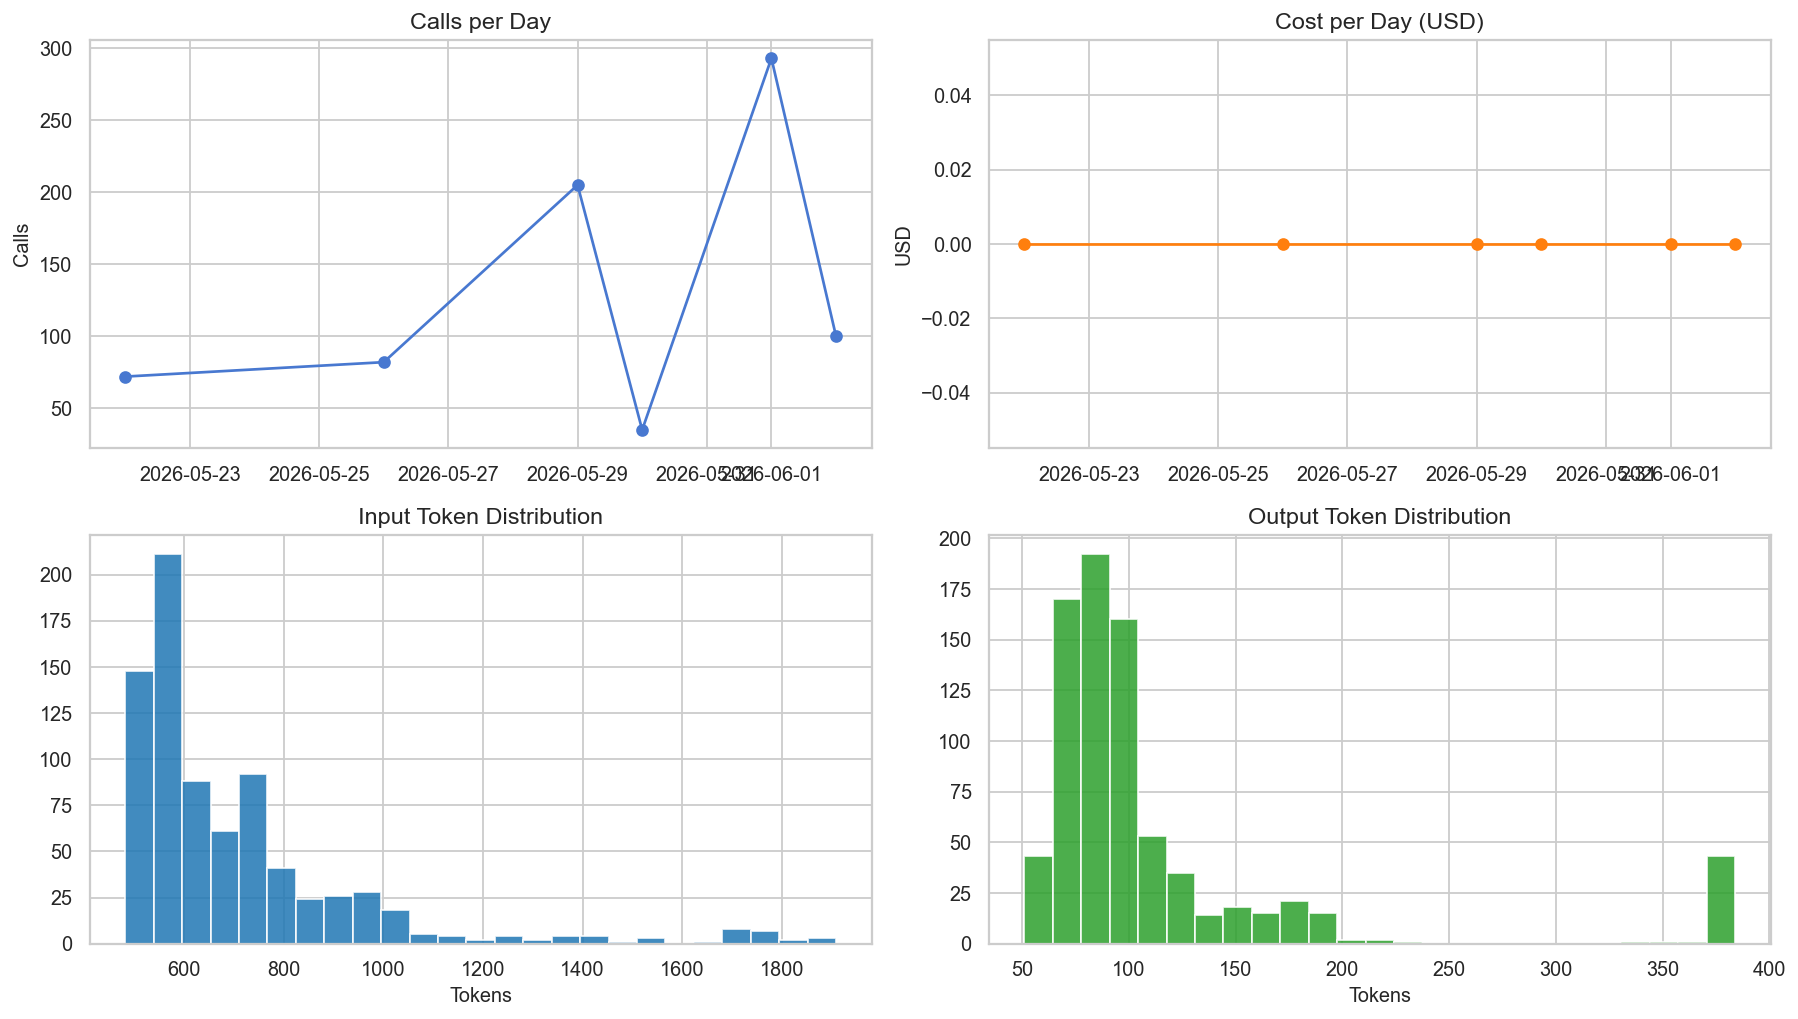

In [17]:
plot_df = df.sort_values('timestamp').copy()
plot_df['date'] = plot_df['timestamp'].dt.date

daily = plot_df.groupby('date').agg(
    calls=('timestamp','count'),
    cost=('total_cost_usd','sum'),
    input_tokens=('input_tokens','sum'),
    output_tokens=('output_tokens','sum'),
)
daily.index = pd.to_datetime(daily.index)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0,0].plot(daily.index, daily['calls'], marker='o')
axes[0,0].set_title('Calls per Day'); axes[0,0].set_ylabel('Calls')

axes[0,1].plot(daily.index, daily['cost'], marker='o', color='tab:orange')
axes[0,1].set_title('Cost per Day (USD)'); axes[0,1].set_ylabel('USD')

ok = plot_df[~plot_df['is_error']]
axes[1,0].hist(ok['input_tokens'], bins=25, color='tab:blue', alpha=0.85)
axes[1,0].set_title('Input Token Distribution'); axes[1,0].set_xlabel('Tokens')

axes[1,1].hist(ok['output_tokens'], bins=25, color='tab:green', alpha=0.85)
axes[1,1].set_title('Output Token Distribution'); axes[1,1].set_xlabel('Tokens')

plt.tight_layout(); plt.show()


## 4. Cost & errors by agent

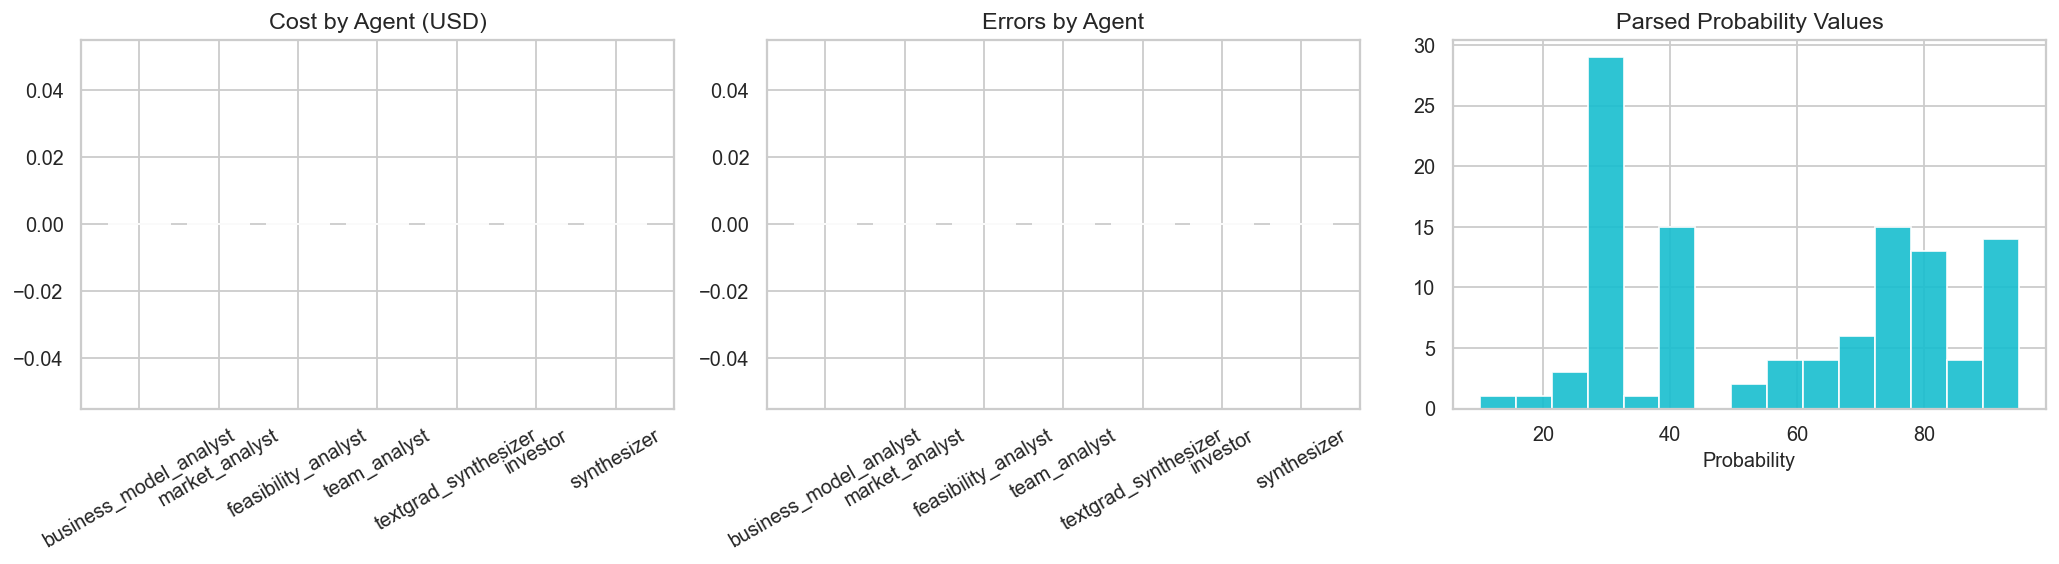

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

agent_costs = by_agent['cost_usd'].sort_values(ascending=False)
axes[0].bar(agent_costs.index.astype(str), agent_costs.values, color='tab:purple')
axes[0].set_title('Cost by Agent (USD)')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(by_agent.index.astype(str), by_agent['errors'].values, color='tab:red')
axes[1].set_title('Errors by Agent')
axes[1].tick_params(axis='x', rotation=30)

valid_probs = df['probability'].dropna()
if len(valid_probs):
    axes[2].hist(valid_probs, bins=15, color='tab:cyan', alpha=0.9)
axes[2].set_title('Parsed Probability Values')
axes[2].set_xlabel('Probability')

plt.tight_layout(); plt.show()


## 5. Recent model outputs

In [19]:
recent = df.loc[df['has_response']].head(10)
for _, row in recent.iterrows():
    ts   = str(row['timestamp'])[:19]
    agent = row.get('agent_name', '?')
    resp  = str(row['assistant_response'])[:300]
    print(f"[{ts}] {agent}")
    print(resp)
    print()


[2026-06-02 18:24:35] textgrad_synthesizer
```json
{
  "decision": "INVEST",
  "probability": 65,
  "num_promising": 4,
  "num_not_promising": 0,
  "avg_confidence": 82.5,
  "conflicts": "",
  "reasoning": "The startup demonstrates strong market potential, a viable business model with scalability, and positive traction. The team has domain e

[2026-06-02 18:21:13] market_analyst
```json
{
  "decision": "PROMISING",
  "confidence": 85,
  "rationale": "The travel sector in 2013 is attractive due to the growing demand for authentic experiences, and [ORG] addresses an underserved market. Being based in Silicon Valley provides access to a strong ecosystem. However, the competiti

[2026-06-02 18:20:02] feasibility_analyst
{
  "decision": "PROMISING",
  "confidence": 80,
  "rationale": "The product is viable with clear differentiation in the travel sector, addressing a need for authentic experiences. Execution risk is moderate due to the complexity of building and maintaining a global communi